# Machine Learning
### Binomial and multinomial distributions
The **Binomial distribution** is a **discrete** probability distribution extending the **Bernoulli** distribution. The binomial distribution models the probability of getting exactly $x$ (a non-negative integer) successes in $n$ independent Bernoulli trials, where each trial has two possible outcomes: **success** or **failure**, with fixed probability $p$.
<br> **Reminder:** In **Bernoulli** distribution, we model a single random experiment with only two possible outcomes:
- Success (often coded as 1) with probability $p$,
- Failure (coded as 0) with probability $1−p$.

Specifically, if we let:
- $n =$ number of independent trials
- $p =$ probability of success on each trial
- $q = 1 - p =$ probability of failure
- $X =$ number of successes in $n$ trials

Then, the **Probability mass function (PMF)** for a random variable $X\sim Binomial(n,p)$ is:
<br> $\large P(X=x)=\binom{n}{x}\cdot p^x \cdot (1-p)^{n-x}$, $x\in\{0,1,...,n\}$
<br> Where:
- $\binom{n}{x}=$ number of ways to choose $x$ successes from $n$ trials (combinations)
- $p^x=$ probability of $x$ successes
- $(1-p)^{n-x}=$ probability of $n-x$ failures




Some **properties** of Binomial distribution with probability of success $p$ in $n$ trials:
- Mean: $E[X]=n\cdot p$
- Variance: $Var[X]=n\cdot p\cdot (1-p)$

**Example 1:** Flip a fair coin 5 times. What’s the probability of getting exactly 3 heads?
<br>*Answer*: From the question, we get: $n=5$, $p=0.5$ (a fair coin), and $x=3$. So, we put them in the formula of the Binomial PMF:
- $P(X=3)=\binom{5}{3}(0.5)^3 (0.5)^2=\frac{5}{16}=0.3125$ 

<hr style="height:2px;">

**Multinomial distribution:** When we have exactly $k$ possible outcomes (e.g., categories), and we perform $n$ independent trials (e.g., 10 dice rolls); each trial results in one of the $k$ outcomes, where $k$ may be greater than two. In this case, we are dealing with a multinomial distribution. Specifically, the **multinomial PMF** is defined as:
<br> $\large P(x_1,x_2,...,x_k)=\frac{n!}{x_1!\cdot x_2!...x_k!}\cdot p_1^{x_1}\cdot p_2^{x_2}...p_k^{x_k}$
<br> Where
- $n=x_1+x_2+...+x_k$  (total number of trials)
- $x_i=$ number of times outcome (category) $i$ has occurred
- $p_i=$ probability of outcome (category) $i$ in a single trial

**Hint:** The **binomial** distribution is a special case of **multinomial** when $k = 2$.

<hr>

**Example 2:** Roll a 6-sided die 10 times. What’s the probability of getting:
- 2 ones, 3 twos, 1 three, 2 fours, 1 five, 1 six?

*Answer*: Assume each face has equal probability: $p_i=1/6$. Then, the probability becomes:
- $P=\frac{10!}{2!\cdot 3!\cdot 1! \cdot 2! \cdot 1! \cdot 1!}\cdot (\frac{1}{6})^{10}\approx0.0025$

<hr>

**Binomial sampling:** If $X_1$, $X_2$, ..., $X_n$ are independent $Bernoulli(p)$ random variables, then their sum $S_n=\sum_{i=1}^n X_i$ follows the $Binomial(n,p)$ distribution. This is one way to generate Binomial samples from Bernoulli distribution. 
- We talked in an earleir post, on how to generate Bernoulli samples from uniform distirbution.

<hr>

In the following:
- We implement some **Python** functions for the **Binomial** distribution, which includes some functions related to the distribution. 
- We also have a function to generate samples of Binomial by a sum of $n$ independent Bernoulli random variables as mentiove above.
- As a bonus, we remind the built-in function `binom` from `scipy.stats`. 
- As an extra code, some functions are made available for multinomial distribution.

<hr>

https://github.com/ostad-ai/Machine-Learning
<br> Explanation: https://www.pinterest.com/HamedShahHosseini/Machine-Learning/

In [1]:
# Import required modules
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------
# 1. Bernoulli Distribution — Generate 0/1 samples
# -------------------------------
def bernoulli_sample(p, size):
    """
    Generate Bernoulli samples (0 or 1) with success probability p.
    """
    u = np.random.uniform(size=size)
    return (u < p).astype(int)

# -------------------------------
# 2. Binomial Sampling: Sum n independent Bernoulli trials
# -------------------------------
def binomial_from_bernoulli(n, p, size):
    """
    Generate binomial samples by summing n independent Bernoulli trials.
    Each sample is sum of n Bernoulli(p) variables.
    """
    # Generate n Bernoulli trials for each sample
    # Shape: (size, n) → sum axis=1 → (size,)
    bernoullis = bernoulli_sample(p, (size, n))
    binomial_samples = np.sum(bernoullis, axis=1)
    return binomial_samples

# -------------------------------
# 3. Binomial PMF & CDF (for reference)
# -------------------------------
def binomial_pmf(n, p, k):
    """
    Compute probability of exactly k successes in n trials.
    """
    if k < 0 or k > n:
        return 0.0
    comb = math.comb(n, k)
    prob = comb * (p ** k) * ((1 - p) ** (n - k))
    return prob

def binomial_cdf(n, p, k):
    """
    Compute P(X <= k)
    """
    if k < 0:
        return 0.0
    if k >= n:
        return 1.0
    total = 0.0
    for i in range(k + 1):
        total += binomial_pmf(n, p, i)
    return total

# -------------------------------
# 4. Mean and Variance
# -------------------------------
def binomial_stats(n, p):
    """
    Compute mean and variance of binomial distribution.
    """
    mean = n * p
    var = n * p * (1 - p)
    return mean, var

# -------------------------------
# 5. Visualization Function
# -------------------------------
def plot_binomial(n, p, title="Binomial Distribution"):
    """
    Plot PMF and CDF.
    """
    k_values = list(range(n + 1))
    pmf_values = [binomial_pmf(n, p, k) for k in k_values]
    cdf_values = [binomial_cdf(n, p, k) for k in k_values]
    
    plt.figure(figsize=(10, 5))
    
    # PMF
    plt.subplot(1, 2, 1)
    plt.bar(k_values, pmf_values, color='blue', edgecolor='black')
    plt.title(f"PMF: {title}")
    plt.xlabel("Number of Successes (k)")
    plt.ylabel("Probability P(X = k)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # CDF
    plt.subplot(1, 2, 2)
    plt.plot(k_values, cdf_values, marker='o', color='green', linestyle='-', linewidth=2)
    plt.title(f"CDF: {title}")
    plt.xlabel("Number of Successes (k)")
    plt.ylabel("Cumulative Probability P(X <= k)")
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

=== Example 1: 10 coin flips, P(heads) = 0.5 ===
Mean = 5.0
Variance = 2.5
Sample mean = 4.9
Sample variance = 2.67


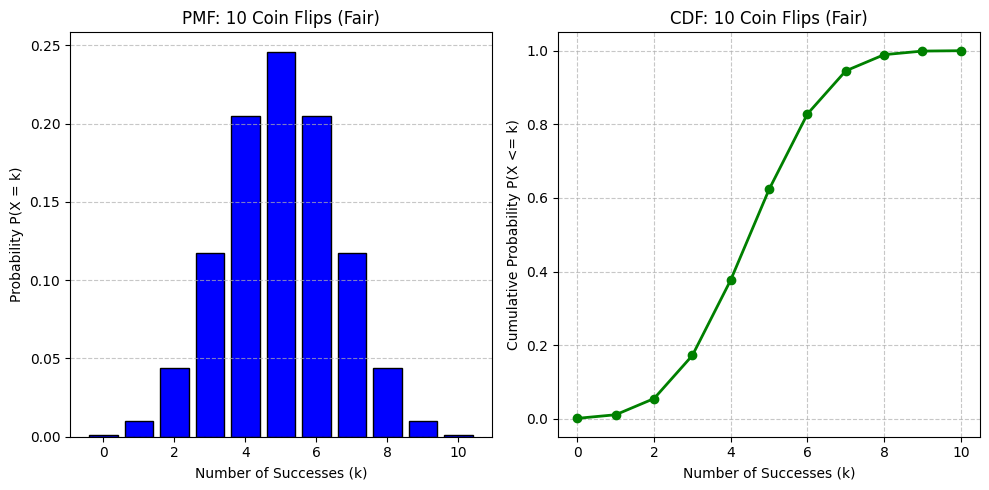

In [3]:
# -------------------------------
# 6. Example Usage: Generate Samples
# -------------------------------

print("=== Example 1: 10 coin flips, P(heads) = 0.5 ===")
n = 10
p = 0.5

print(f"Mean = {n * p}")
print(f"Variance = {n * p * (1 - p)}")

# Generate 1000 samples
samples = binomial_from_bernoulli(n, p, 1000)
print(f"Sample mean = {np.mean(samples)}")
print(f"Sample variance = {np.var(samples)}")

# Plot
plot_binomial(n, p, "10 Coin Flips (Fair)")


=== Example 2: 100 patients, 60% success rate ===
Sample mean = 59.833
Sample variance = 22.965111


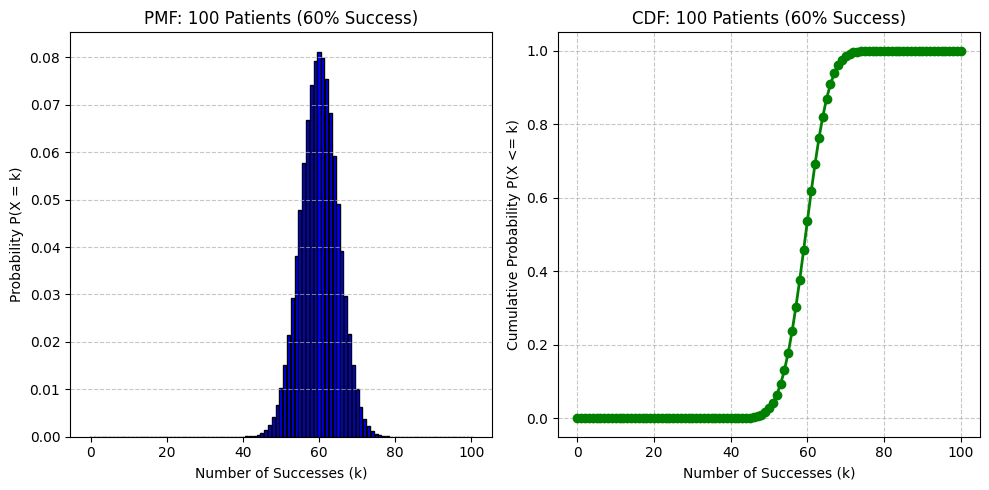

In [4]:
# -------------------------------
# Example 2: Medical trial — 100 patients, 60% success rate
# -------------------------------
print("\n=== Example 2: 100 patients, 60% success rate ===")
n = 100
p = 0.6

samples_med = binomial_from_bernoulli(n, p, 1000)
print(f"Sample mean = {np.mean(samples_med)}")
print(f"Sample variance = {np.var(samples_med)}")

plot_binomial(n, p, "100 Patients (60% Success)")


=== Example 3: Spam Detection — 500 emails, 20% spam ===
Sample mean = 100.013
Sample variance = 76.128831


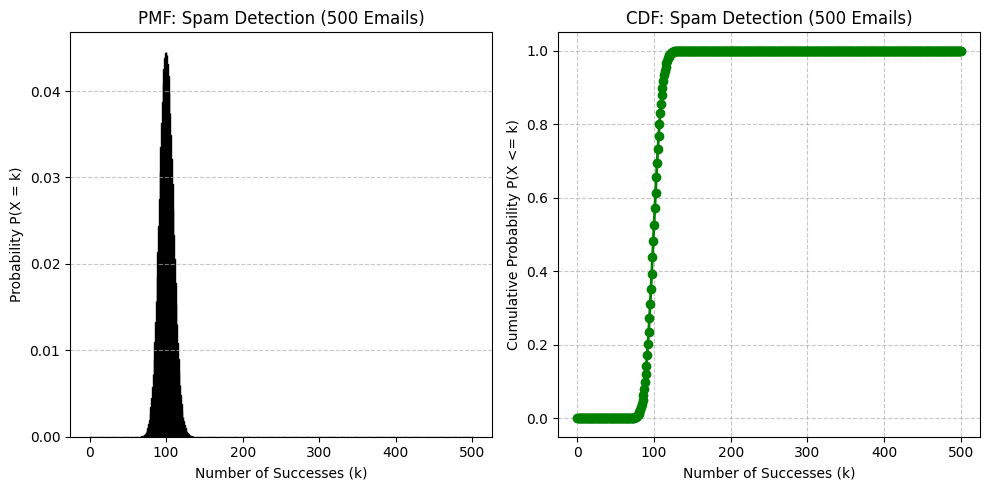

In [5]:
# -------------------------------
# Example 3: Spam Detection — 500 emails, 20% spam
# -------------------------------
print("\n=== Example 3: Spam Detection — 500 emails, 20% spam ===")
n = 500
p = 0.2

samples_spam = binomial_from_bernoulli(n, p, 1000)
print(f"Sample mean = {np.mean(samples_spam)}")
print(f"Sample variance = {np.var(samples_spam)}")

plot_binomial(n, p, "Spam Detection (500 Emails)")

<hr style="height:3px;background:lightgreen">

# Bonus
#### Compare with scipy.stats.binom

In [6]:
# -------------------------------
# ✅ Bonus: Compare with scipy.stats.binom
# -------------------------------
from scipy.stats import binom

print("\n=== Comparison with scipy.stats.binom ===")
n = 10
p = 0.5
size = 1000

# Generate samples using scipy
scipy_samples = binom.rvs(n, p, size=size)

print(f"Scipy sample mean = {np.mean(scipy_samples)}")
print(f"Scipy sample variance = {np.var(scipy_samples)}")
print(f"Scipy mean = {binom.mean(n, p)}")
print(f"Scipy variance = {binom.var(n, p)}")

# Check if our samples are similar
print(f"Mean difference: {abs(np.mean(samples) - np.mean(scipy_samples))}")
print(f"Variance difference: {abs(np.var(samples) - np.var(scipy_samples))}")


=== Comparison with scipy.stats.binom ===
Scipy sample mean = 5.073
Scipy sample variance = 2.2776710000000002
Scipy mean = 5.0
Scipy variance = 2.5
Mean difference: 0.17300000000000004
Variance difference: 0.3923289999999997


<hr style="height:3px; background:lightblue">

# Extra
#### Some functions related to multinomial distribution

In [7]:
# -------------------------------
# 1. Multinomial PMF — Probability of specific counts
# -------------------------------
def multinomial_pmf(n, p, counts):
    """
    Compute probability of specific counts for each category.
    counts: list of integers (e.g., [2, 3, 1] for 3 categories)
    p: list of probabilities (e.g., [0.2, 0.5, 0.3])
    n: total number of trials
    """
    if len(counts) != len(p):
        raise ValueError("Number of categories must match number of probabilities")
    if sum(counts) != n:
        raise ValueError("Sum of counts must equal n")
    if any(c < 0 for c in counts):
        raise ValueError("Counts cannot be negative")
    if any(p_i < 0 or p_i > 1 for p_i in p):
        raise ValueError("Probabilities must be between 0 and 1")

    # Multinomial coefficient: n! / (c1! * c2! * ... * ck!)
    multinom_coeff = math.factorial(n)
    for c in counts:
        multinom_coeff //= factorial(c)

    # Product of probabilities
    prob = 1.0
    for i in range(len(p)):
        prob *= (p[i] ** counts[i])

    return multinom_coeff * prob

# -------------------------------
# 2. Mean and Variance
# -------------------------------
def multinomial_stats(n, p):
    """
    Compute mean and variance for each category.
    """
    mean = np.array([n * p_i for p_i in p])
    var = np.array([n * p_i * (1 - p_i) for p_i in p])
    return mean, var

# -------------------------------
# 3. Sample from Multinomial Distribution
# -------------------------------
def multinomial_sample(n, p, size):
    """
    Generate samples from multinomial distribution.
    Each sample is a vector of counts for each category.
    """
    # Generate random samples using numpy's multinomial
    # This is the most efficient and accurate method
    return np.random.multinomial(n, p, size=size)

In [8]:
# -------------------------------
# 1. Example Usage: Dice Rolls — 6 Sides, 10 Rolls
# -------------------------------
print("=== Example 1: 6-sided die, 10 rolls ===")
n = 10
p = [1/6] * 6  # Equal probability for each face

mean_die,var_die=multinomial_stats(n,p)
print(f"Mean = {mean_die}")
print(f"Variance = {var_die}")

# Generate 1000 samples
samples = multinomial_sample(n, p, 1000)
print(f"Sample mean = {np.mean(samples, axis=0)}")
print(f"Sample variance = {np.var(samples, axis=0)}")

=== Example 1: 6-sided die, 10 rolls ===
Mean = [1.66666667 1.66666667 1.66666667 1.66666667 1.66666667 1.66666667]
Variance = [1.38888889 1.38888889 1.38888889 1.38888889 1.38888889 1.38888889]
Sample mean = [1.704 1.641 1.636 1.659 1.693 1.667]
Sample variance = [1.594384 1.280119 1.405504 1.440719 1.396751 1.382111]
